# 1+1 ga on string matching

In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
def ga_with_selection(l=100, mu=None, max_gen=1500):
    if mu is None:
        mu = 1 / l
    x = np.random.randint(0, 2, l)
    history = [np.sum(x)]
 
    for _ in range(max_gen):
        xm = x.copy()
        mask = np.random.random(l) < mu # whether to switch given bit
        xm[mask] = 1 - xm[mask]
        if np.sum(xm) >= np.sum(x):
            x = xm
        history.append(np.sum(x))
        
 
    return history


Final fitness: 100/100 after 1500 generations
Optimum reached within 1500 generations


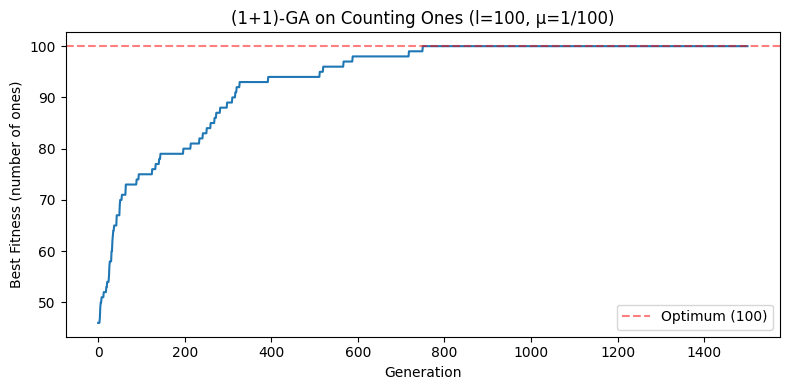

In [3]:
l = 100
history = ga_with_selection(l=l, max_gen=1500)
 
plt.figure(figsize=(8, 4))
plt.plot(history, linewidth=1.5)
plt.axhline(y=l, color='r', linestyle='--', alpha=0.5, label='Optimum (100)')
plt.xlabel('Generation')
plt.ylabel('Best Fitness (number of ones)')
plt.title(f'(1+1)-GA on Counting Ones (l={l}, µ=1/{l})')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/q1_single_run.png', dpi=150)
 
print(f"Final fitness: {history[-1]}/{l} after {len(history)-1} generations")
print(f"Optimum {'reached' if history[-1] == l else 'not reached'} within 1500 generations")

# leave out the selection of better individual

In [4]:
def ga_without_selection(l=100, mu=None, max_gen=1500):
    if mu is None:
        mu = 1 / l
    x = np.random.randint(0, 2, l)
    best = np.sum(x)
    history = [best]
 
    for _ in range(max_gen):
        xm = x.copy()
        mask = np.random.random(l) < mu
        xm[mask] = 1 - xm[mask]
        x = xm  # always replace, no selection
        best = max(best, np.sum(x))
        history.append(best)
 
    return history

Single run — with selection: 99, without: 63


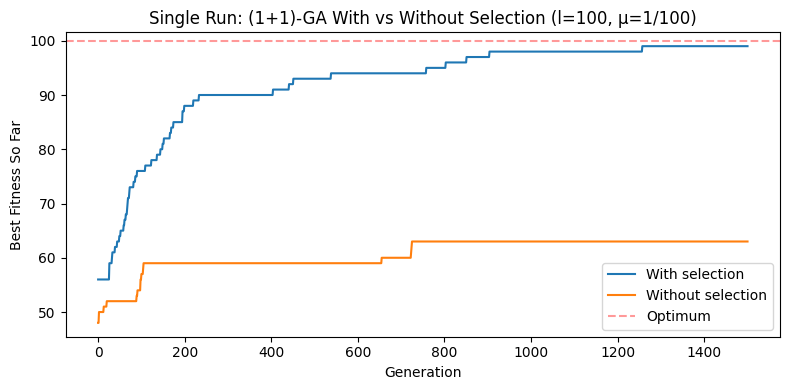

In [5]:
l = 100
max_gen =1_500
np.random.seed(42)
h_sel = ga_with_selection(l, max_gen=max_gen)
h_nosel = ga_without_selection(l, max_gen=max_gen)
 
plt.figure(figsize=(8, 4))
plt.plot(h_sel, label='With selection', linewidth=1.5)
plt.plot(h_nosel, label='Without selection', linewidth=1.5)
plt.axhline(y=l, color='r', linestyle='--', alpha=0.4, label='Optimum')
plt.xlabel('Generation')
plt.ylabel('Best Fitness So Far')
plt.title(f'Single Run: (1+1)-GA With vs Without Selection (l={l}, µ=1/{l})')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/q2_single_run.png', dpi=150)
print(f"Single run — with selection: {h_sel[-1]}, without: {h_nosel[-1]}")
 

## multiple runs evaluation


50 runs — final fitness:
  With selection:    99.9 ± 0.2
  Without selection: 63.0 ± 2.5
  Optimum reached — with: 47/50, without: 0/50


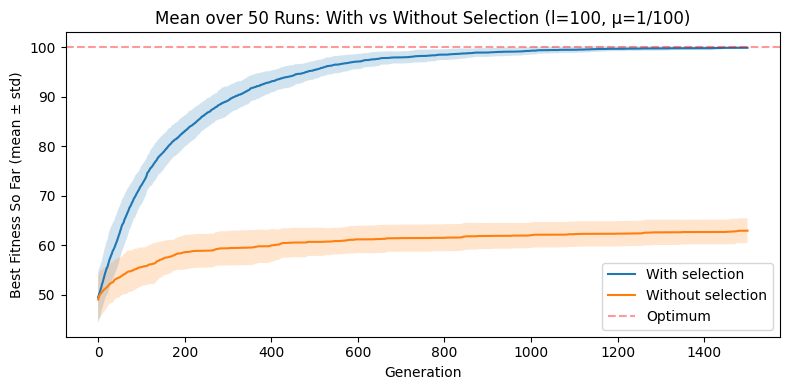

In [6]:
n_runs =50
results_sel = np.zeros((n_runs, max_gen + 1))
results_nosel = np.zeros((n_runs, max_gen + 1))
 
for i in range(n_runs):
    results_sel[i] = ga_with_selection(l, max_gen=max_gen)
    results_nosel[i] = ga_without_selection(l, max_gen=max_gen)
 
mean_sel = results_sel.mean(axis=0)
mean_nosel = results_nosel.mean(axis=0)
std_sel = results_sel.std(axis=0)
std_nosel = results_nosel.std(axis=0)
 
gens = np.arange(max_gen + 1)
 
plt.figure(figsize=(8, 4))
plt.plot(gens, mean_sel, label='With selection', linewidth=1.5)
plt.fill_between(gens, mean_sel - std_sel, mean_sel + std_sel, alpha=0.2)
plt.plot(gens, mean_nosel, label='Without selection', linewidth=1.5)
plt.fill_between(gens, mean_nosel - std_nosel, mean_nosel + std_nosel, alpha=0.2)
plt.axhline(y=l, color='r', linestyle='--', alpha=0.4, label='Optimum')
plt.xlabel('Generation')
plt.ylabel('Best Fitness So Far (mean ± std)')
plt.title(f'Mean over {n_runs} Runs: With vs Without Selection (l={l}, µ=1/{l})')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/q4_multi_run.png', dpi=150)
 
print(f"\n{n_runs} runs — final fitness:")
print(f"  With selection:    {mean_sel[-1]:.1f} ± {std_sel[-1]:.1f}")
print(f"  Without selection: {mean_nosel[-1]:.1f} ± {std_nosel[-1]:.1f}")
print(f"  Optimum reached — with: {np.sum(results_sel[:,-1]==l)}/{n_runs}, without: {np.sum(results_nosel[:,-1]==l)}/{n_runs}")